# 📋 Overview
This notebook evaluates a **hybrid phishing detection workflow** using:
1. **Machine Learning (ML) Ensemble / Pretrained Model** – Fast first-line classification  
2. **Large Language Models (LLMs)** – Review of the most uncertain ML mistakes

---

## 🎯 Objective
Assess how well different LLMs perform at correcting **only the hardest ML mistakes**, without retraining or fully applying LLMs to all emails.  
The goal is to improve accuracy **efficiently**, focusing LLM attention where it's most needed.

---

## 📊 Workflow
1. **Load dataset** from parquet file (`test-00000-of-00001-8a6d39996ec0fb5b.parquet`)
   - Contains `text_combined` (email content) and `label` (0=Safe, 1=Phishing)
2. **ML predictions**: Use the pretrained model to classify all emails  
3. **Identify ML mistakes** and rank them by uncertainty (simulated confidence)  
4. **Select a limited subset** of the most uncertain mistakes for each LLM (e.g., 25 emails)  
5. **LLM evaluation**: Each LLM classifies the subset independently  
6. **Compare LLM performance** on ML mistakes using metrics (Accuracy, Precision, Recall, F1)

---

## 📁 Dataset
- **Source**: `test-00000-of-00001-8a6d39996ec0fb5b.parquet`
- **Columns**: 
  - `text_combined`: Email text content
  - `label`: Binary classification (0 = Safe, 1 = Phishing)
- **Format**: Parquet file (converted to CSV)

In [1]:
import pandas as pd 
import numpy as np 
import re 
import os 
import joblib 
import time 
import matplotlib.pyplot as plt 
import seaborn as sns 
from tqdm import tqdm 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix 
from openai import OpenAI as OR_OpenAI 
from dotenv import load_dotenv 
from IPython.display import display

In [2]:
# Load .env into environment
load_dotenv()

# OpenRouter client (single API key to call multiple models)
OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")
if not OPENROUTER_KEY:
    print("⚠️ OPENROUTER_API_KEY not found in .env. LLM calls will fail.")
    openrouter_client = None
else:
    try:
        openrouter_client = OR_OpenAI(api_key=OPENROUTER_KEY, base_url="https://openrouter.ai/api/v1")
        print("✅ OpenRouter client configured.")
    except Exception as e:
        openrouter_client = None
        print("⚠️ Failed to create OpenRouter client:", e)


MODEL_IDS = {
    "DeepSeek": "deepseek/deepseek-chat-v3.1",     
    "GPT": "openai/gpt-4.1",                       
    "Claude": "anthropic/claude-3.5-sonnet",            
}

# Thin wrapper — single function to call OpenRouter with chosen model name
def call_openrouter_model(prompt: str, model_id: str, temperature: float = 0.3, timeout: int = 30):
    """
    Calls OpenRouter chat completions using provided model_id.
    Returns (text, status) where status is "ok" or "error".
    """
    if openrouter_client is None:
        return ("❌ OpenRouter client not configured.", "error")
    try:
        resp = openrouter_client.chat.completions.create(
            model=model_id,
            messages=[{"role":"user","content":prompt}],
            temperature=temperature,
            max_tokens=800,
        )
        txt = resp.choices[0].message.content.strip()
        return (txt, "ok")
    except Exception as e:
        return (f"❌ OpenRouter request failed: {e}", "error")

✅ OpenRouter client configured.


In [3]:
# Load parquet file
parquet_path = "test-00000-of-00001-8a6d39996ec0fb5b.parquet"
df = pd.read_parquet(parquet_path)

print(f"✅ Loaded Dataset → {df.shape}")

# Convert parquet to CSV
csv_path = "test_dataset.csv"
df.to_csv(csv_path, index=False)
print(f"✅ Saved as CSV → {csv_path}")

# Standardize columns to match the rest of the notebook
df = df[['text_combined', 'label']]
df.rename(columns={"text_combined": "email_text"}, inplace=True)

# Drop NaN and duplicates
df = df.dropna(subset=['email_text', 'label'])
df = df.drop_duplicates(subset=['email_text'], keep='first')

# Clean text
def clean_text(text):
    text = re.sub(r'_+', ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['email_text'] = df['email_text'].astype(str).apply(clean_text)
df = df[df['email_text'] != '']

df['label'] = df['label'].astype(int)

df = df.reset_index(drop=True)
print(f"\n✅ Cleaned dataset ready: {df.shape}")
print(df['label'].value_counts())

✅ Loaded Dataset → (16498, 2)
✅ Saved as CSV → test_dataset.csv

✅ Cleaned dataset ready: (16478, 2)
label
1    8592
0    7886
Name: count, dtype: int64


In [4]:
print("\n" + "="*60)
print("📊 DATASET SAMPLE")
print("="*60)

# Show first few rows
print("\n🔍 First 5 rows:")
display(df.head())

# Show random sample
print("\n🎲 Random 5 rows:")
display(df.sample(n=5, random_state=42))

# Show basic statistics
print("\n📈 Dataset Statistics:")
print(f"Total emails: {len(df)}")
print(f"Phishing emails (label=1): {(df['label'] == 1).sum()} ({(df['label'] == 1).sum()/len(df)*100:.2f}%)")
print(f"Safe emails (label=0): {(df['label'] == 0).sum()} ({(df['label'] == 0).sum()/len(df)*100:.2f}%)")
print(f"\nAverage email length: {df['email_text'].str.len().mean():.0f} characters")
print(f"Min email length: {df['email_text'].str.len().min()} characters")
print(f"Max email length: {df['email_text'].str.len().max()} characters")

# Show one example of each class
print("\n" + "="*60)
print("📧 SAMPLE PHISHING EMAIL (label=1):")
print("="*60)
phishing_example = df[df['label'] == 1].iloc[0]['email_text']
print(phishing_example[:500] + "..." if len(phishing_example) > 500 else phishing_example)

print("\n" + "="*60)
print("📧 SAMPLE SAFE EMAIL (label=0):")
print("="*60)
safe_example = df[df['label'] == 0].iloc[0]['email_text']
print(safe_example[:500] + "..." if len(safe_example) > 500 else safe_example)
print("="*60)


📊 DATASET SAMPLE

🔍 First 5 rows:


,email_text,label
0,col kobia abuom col kobia aabuomshecom dear si...,1
1,vicky coker vickydipbadajozes well teach grow ...,1
2,aschsoft inc uabruntchainsawsculpturescouk dea...,1
3,first line defense stop virus spam email r xxx...,1
4,chris garrigues cwgexmhdeepeddycom exmh 556486...,0



🎲 Random 5 rows:


,email_text,label
9670,joshua schachter urxptlbyahooinccom didnt add ...,0
6162,ken williams jqsrgvogmailcom nov john e malmbe...,0
10792,terry stewart carlauschwitzcollinseuropaeu siz...,1
8523,december course offerings december course titl...,0
3909,sehr geehter sehr geehter mein name ist roland...,1



📈 Dataset Statistics:
Total emails: 16478
Phishing emails (label=1): 8592 (52.14%)
Safe emails (label=0): 7886 (47.86%)

Average email length: 1188 characters
Min email length: 3 characters
Max email length: 128947 characters

📧 SAMPLE PHISHING EMAIL (label=1):
col kobia abuom col kobia aabuomshecom dear sir feel sorry interrupt peace since expecting receive mail mehoweveri obliged due importance urgency massagei crave indulgenceand want reassure mean well mutual goodso please embbarrassed suspicious col kobia abuom got know courtesy international business bureau thailandsequel zeal towards foreign investment also security life possession therefore write give breakdown proposal personal confidant first vicepresident dr john garang southern sudan whose ...

📧 SAMPLE SAFE EMAIL (label=0):
chris garrigues cwgexmhdeepeddycom exmh 556486408p contenttype textplain charsetusascii anders eriksson date thu jul next report every seems left exmh new messages arrived folder tell picks message sim

In [5]:
# Paths
model_path = os.path.join("..", "ML pipeline", "model.pkl")
vectorizer_path = os.path.join("..", "ML pipeline", "tfidf_vectorizer.pkl")

# Load trained model and vectorizer
model = joblib.load(model_path)
vectorizer = joblib.load(vectorizer_path)
print("✅ Loaded ML model and TF-IDF vectorizer")

# Transform new email text
X_new_tfidf = vectorizer.transform(df['email_text'])

# True labels
y_true = df['label']

# Predict with ML model
ml_pred = model.predict(X_new_tfidf)
df['ml_pred'] = ml_pred

# ML performance
ml_accuracy = accuracy_score(y_true, ml_pred)
ml_precision = precision_score(y_true, ml_pred)
ml_recall = recall_score(y_true, ml_pred)
ml_f1 = f1_score(y_true, ml_pred)
ml_cm = confusion_matrix(y_true, ml_pred)

print("\n📊 ML-ONLY PERFORMANCE ON NEW DATASET")
print(f"Accuracy : {ml_accuracy:.4f}")
print(f"Precision: {ml_precision:.4f}")
print(f"Recall   : {ml_recall:.4f}")
print(f"F1 Score : {ml_f1:.4f}")
print("\nConfusion Matrix:")
print(ml_cm)

# Identify ML mistakes
ml_mistakes = df[df['ml_pred'] != df['label']].copy()
print(f"\n❌ ML mistakes found: {len(ml_mistakes)}")

✅ Loaded ML model and TF-IDF vectorizer

📊 ML-ONLY PERFORMANCE ON NEW DATASET
Accuracy : 0.9030
Precision: 0.9183
Recall   : 0.8935
F1 Score : 0.9057

Confusion Matrix:
[[7203  683]
 [ 915 7677]]

❌ ML mistakes found: 1598


In [6]:
print("\n" + "="*60)
print("⏱️ ML-ONLY PREDICTION TIME")
print("="*60)

start_ml = time.perf_counter()

X_new_tfidf = vectorizer.transform(df['email_text'])
ml_pred = model.predict(X_new_tfidf)

ml_time = time.perf_counter() - start_ml
ml_time_per_email = ml_time / len(df)

print(f"Total ML prediction time: {ml_time:.4f} seconds")
print(f"Average time per email:  {ml_time_per_email*1000:.2f} ms")


⏱️ ML-ONLY PREDICTION TIME
Total ML prediction time: 5.6958 seconds
Average time per email:  0.35 ms


In [7]:
# ✅ Identify ML mistakes
ml_mistakes = df[df['ml_pred'] != df['label']].copy()
# Simulate uncertainty for demo purposes
ml_mistakes['confidence'] = np.random.rand(len(ml_mistakes))

# Pick 25 most uncertain mistakes (lowest confidence)
uncertain_mistakes = ml_mistakes.nsmallest(25, 'confidence')
print(f"Selected {len(uncertain_mistakes)} most uncertain ML mistakes for LLM review")
display(uncertain_mistakes[['email_text', 'ml_pred', 'label', 'confidence']])

Selected 25 most uncertain ML mistakes for LLM review


,email_text,ml_pred,label,confidence
9351,johnathan thornton wilburpropagandasantostotal...,0,1,0.000953
8174,gkmpettingzoonet glen mccready forwardedby sve...,1,0,0.001679
9590,googleadwords supportadwordsgooglecom dear adv...,0,1,0.002795
4261,gracieuse find toprated mens products httpwwwr...,0,1,0.002850
7569,daily top esnizthc 1969vdccomvn daily top cnnc...,0,1,0.003679
14566,daily top entists 1999regentedu daily top cnnc...,0,1,0.005311
11995,daily top charrlikievipuhfavaloroeduar daily t...,0,1,0.006287
4414,marika marikatsetvlcu3gstonecom national geogr...,0,1,0.006321
8919,daily top leighannamasglofnsinglewellcomtw dai...,0,1,0.007935
7640,wetransfer supportwetransfercom recipient jose...,0,1,0.008099


In [8]:
providers = list(MODEL_IDS.keys())
llm_time_total = {prov: 0.0 for prov in providers}
llm_call_count = {prov: 0 for prov in providers}

In [9]:
# Create a proper copy to avoid SettingWithCopyWarning
uncertain_mistakes = uncertain_mistakes.copy()

# Prepare columns for LLM predictions and statuses
for prov in providers:
    uncertain_mistakes[f'llm_{prov}_pred'] = None
    uncertain_mistakes[f'llm_{prov}_status'] = None

def llm_to_label(txt: str):
    """Parse LLM response to binary label."""
    txt = txt.lower()
    if "phish" in txt:
        return 1
    elif "safe" in txt:
        return 0
    return None

# Improved cybersecurity expert prompt
def create_classification_prompt(email_text: str) -> str:
    return f"""You are a cybersecurity expert specializing in phishing detection with years of experience analyzing email threats.

Your task is to classify the following email as either 'Phishing' or 'Safe'.

Key indicators to consider:
- Suspicious URLs or links
- Requests for personal/financial information
- Urgency or threatening language
- Spelling/grammar errors
- Unusual requests or offers
- Generic greetings vs personalized content

Email to analyze:
{email_text}

Respond with ONLY one word: either 'Phishing' or 'Safe'."""

# Query each provider
print("\n🤖 Querying LLMs for classification...\n")
for idx, (i, row) in enumerate(uncertain_mistakes.iterrows(), 1):
    email_text = row['email_text']
    print(f"Processing email {idx}/{len(uncertain_mistakes)}...")
    
    for prov in providers:
        model_id = MODEL_IDS[prov]
        prompt = create_classification_prompt(email_text)
        
        start_llm = time.perf_counter()
        resp, status = call_openrouter_model(prompt, model_id)
        elapsed = time.perf_counter() - start_llm
        
        llm_time_total[prov] += elapsed
        llm_call_count[prov] += 1
        
        pred = llm_to_label(resp) if status == "ok" else None
        
        uncertain_mistakes.at[i, f'llm_{prov}_pred'] = pred
        uncertain_mistakes.at[i, f'llm_{prov}_status'] = status
        
        print(f"  {prov}: status={status}, pred={pred}")
        time.sleep(0.5)  # Rate limiting
    print()  # Blank line between emails

print("✅ LLM classification complete!")


🤖 Querying LLMs for classification...

Processing email 1/25...
  DeepSeek: status=ok, pred=1
  GPT: status=ok, pred=1
  Claude: status=ok, pred=1

Processing email 2/25...
  DeepSeek: status=ok, pred=0
  GPT: status=ok, pred=0
  Claude: status=ok, pred=0

Processing email 3/25...
  DeepSeek: status=ok, pred=1
  GPT: status=ok, pred=1
  Claude: status=ok, pred=1

Processing email 4/25...
  DeepSeek: status=ok, pred=1
  GPT: status=ok, pred=1
  Claude: status=ok, pred=1

Processing email 5/25...
  DeepSeek: status=ok, pred=0
  GPT: status=ok, pred=1
  Claude: status=ok, pred=1

Processing email 6/25...
  DeepSeek: status=ok, pred=0
  GPT: status=ok, pred=1
  Claude: status=ok, pred=0

Processing email 7/25...
  DeepSeek: status=ok, pred=1
  GPT: status=ok, pred=0
  Claude: status=ok, pred=1

Processing email 8/25...
  DeepSeek: status=ok, pred=1
  GPT: status=ok, pred=1
  Claude: status=ok, pred=1

Processing email 9/25...
  DeepSeek: status=ok, pred=0
  GPT: status=ok, pred=1
  Claude

In [10]:
# Compute metrics only for emails that were sent to LLMs
print("\n📊 Accuracy of LLMs on 25 uncertain ML mistakes:")
metrics_summary = []

for prov in providers:
    col_pred = f'llm_{prov}_pred'
    # Only consider rows where LLM predicted
    mask = uncertain_mistakes[col_pred].notna()
    y_true_llm = uncertain_mistakes.loc[mask, 'label']
    y_pred_llm = uncertain_mistakes.loc[mask, col_pred].astype(int)
    
    acc = accuracy_score(y_true_llm, y_pred_llm)
    fixed = ((uncertain_mistakes['ml_pred'] != uncertain_mistakes['label']) & 
             (uncertain_mistakes[col_pred] == uncertain_mistakes['label'])).sum()
    
    metrics_summary.append({
        "Provider": prov,
        "Accuracy": acc,
        "ML Mistakes Fixed": fixed
    })
    print(f"{prov} - Accuracy: {acc:.4f}, ML mistakes fixed: {fixed}")

metrics_df = pd.DataFrame(metrics_summary)


📊 Accuracy of LLMs on 25 uncertain ML mistakes:
DeepSeek - Accuracy: 0.6400, ML mistakes fixed: 16
GPT - Accuracy: 0.8000, ML mistakes fixed: 20
Claude - Accuracy: 0.8000, ML mistakes fixed: 20



✅ Saved: ../pictures/llm_comparison_metrics.png


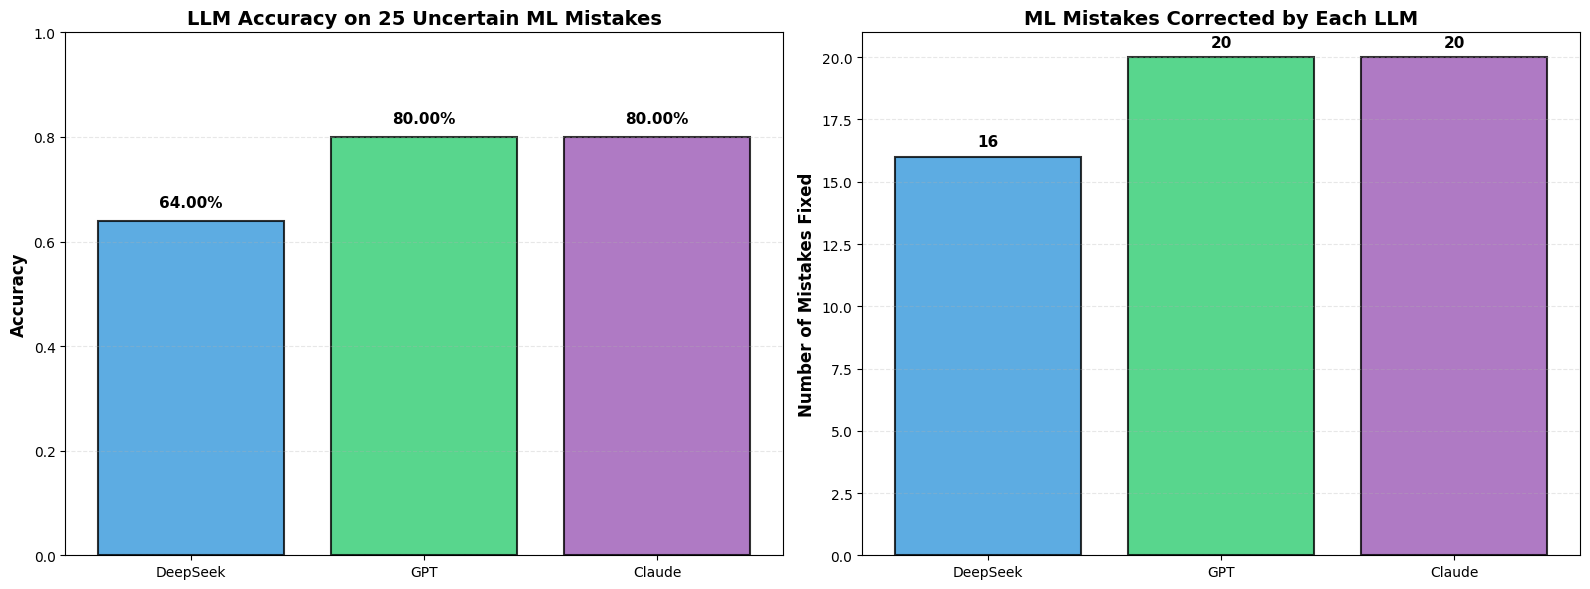


📊 LLM PERFORMANCE SUMMARY
Provider        Accuracy     Mistakes Fixed 
------------------------------------------------------------
DeepSeek        64.00%       16             
GPT             80.00%       20             
Claude          80.00%       20             


In [11]:
# Prepare data for visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Accuracy Comparison
providers_list = [m["Provider"] for m in metrics_summary]
accuracies = [m["Accuracy"] for m in metrics_summary]
colors = ['#3498db', '#2ecc71', '#9b59b6']  # Blue, Green, Purple

ax1.bar(providers_list, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('LLM Accuracy on 25 Uncertain ML Mistakes', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (prov, acc) in enumerate(zip(providers_list, accuracies)):
    ax1.text(i, acc + 0.02, f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. ML Mistakes Fixed
mistakes_fixed = [m["ML Mistakes Fixed"] for m in metrics_summary]

ax2.bar(providers_list, mistakes_fixed, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Mistakes Fixed', fontsize=12, fontweight='bold')
ax2.set_title('ML Mistakes Corrected by Each LLM', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (prov, fixed) in enumerate(zip(providers_list, mistakes_fixed)):
    ax2.text(i, fixed + 0.3, str(fixed), ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig("../pictures/llm_comparison_metrics.png", dpi=300, bbox_inches='tight', facecolor='white')
print("\n✅ Saved: ../pictures/llm_comparison_metrics.png")
plt.show()

# Print summary table
print("\n" + "="*60)
print("📊 LLM PERFORMANCE SUMMARY")
print("="*60)
print(f"{'Provider':<15} {'Accuracy':<12} {'Mistakes Fixed':<15}")
print("-" * 60)
for m in metrics_summary:
    print(f"{m['Provider']:<15} {m['Accuracy']:<12.2%} {m['ML Mistakes Fixed']:<15}")
print("="*60)

In [12]:
print("\n" + "="*60)
print("⏱️ LLM TIMING FOR 25 UNCERTAIN ML MISTAKES")
print("="*60)

for prov in providers:
    total_time = llm_time_total[prov]
    calls = llm_call_count[prov]

    if calls == 0:
        continue

    avg_time = total_time / calls

    print(f"\n{prov}")
    print(f"   Total LLM time: {total_time:.2f} seconds")
    print(f"   Calls made:     {calls}")
    print(f"   Avg per email:  {avg_time:.2f} seconds")


⏱️ LLM TIMING FOR 25 UNCERTAIN ML MISTAKES

DeepSeek
   Total LLM time: 52.64 seconds
   Calls made:     25
   Avg per email:  2.11 seconds

GPT
   Total LLM time: 15.22 seconds
   Calls made:     25
   Avg per email:  0.61 seconds

Claude
   Total LLM time: 32.78 seconds
   Calls made:     25
   Avg per email:  1.31 seconds
